In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv(r'C:\Users\renee\Projects\BuyHerePayLater_Credit_Prediction\Data\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')



df.head(10)

print(df.shape)

(10345, 17)


In [84]:
#Filtering Columns 
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='str')

In [85]:
#Keeping only rows needed for research
df = df[['age', 'monthly_income', 'credit_score',
        'product_category', 
       'repayment_delay_days', 'missed_payments',
        'location',
       'debt_to_income_ratio', 'risk_score', 'customer_segment']]

In [86]:
df.dtypes

age                       int64
monthly_income          float64
credit_score              int64
product_category            str
repayment_delay_days      int64
missed_payments           int64
location                    str
debt_to_income_ratio    float64
risk_score              float64
customer_segment            str
dtype: object

In [87]:
# Change monthly_income to (int) from float64
df['monthly_income'] = df['monthly_income'].astype(int)



In [88]:
#checking for missing values
df.isna()

df.isna().sum()

age                     0
monthly_income          0
credit_score            0
product_category        0
repayment_delay_days    0
missed_payments         0
location                0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

In [89]:
#checking for duplicates
df.duplicated(keep=False).sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
10340    False
10341    False
10342    False
10343    False
10344    False
Length: 10345, dtype: bool>

In [90]:
df['location'].value_counts()

location
Germany      1760
Canada       1740
USA          1736
India        1723
Australia    1722
UK           1664
Name: count, dtype: int64

In [91]:
df['age'].value_counts()

age
26    274
51    268
53    266
35    266
20    265
55    262
21    261
45    260
28    260
24    259
40    259
57    257
50    255
43    252
54    251
59    251
31    251
39    250
46    250
33    248
49    248
52    247
27    247
19    244
32    244
44    243
42    243
22    242
48    239
30    238
36    236
37    234
29    233
47    231
38    231
25    231
56    227
58    227
34    225
41    225
23    223
18    222
Name: count, dtype: int64

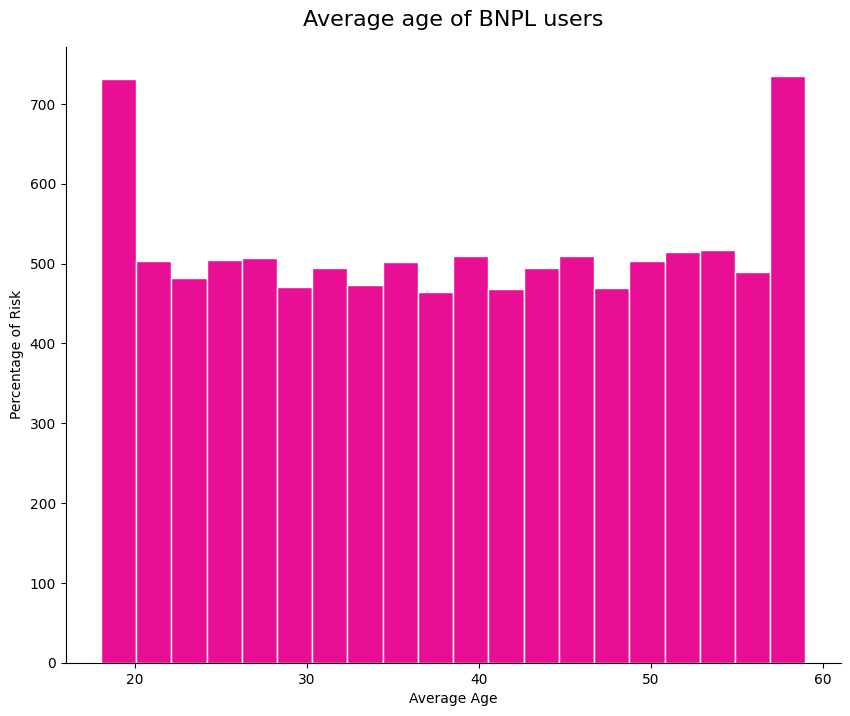

In [92]:
#Which age group are at the hightest risk 
#Visualation (Histogram)


plt.figure(figsize=(10,8))
plt.hist(
    df["age"],
    bins=20,
    color="#e90f95",
    edgecolor = "white"
)


plt.xlabel("Average Age")
plt.ylabel("Percentage of Risk")
plt.title("Average age of BNPL users", fontsize=16, pad=15)

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()
    

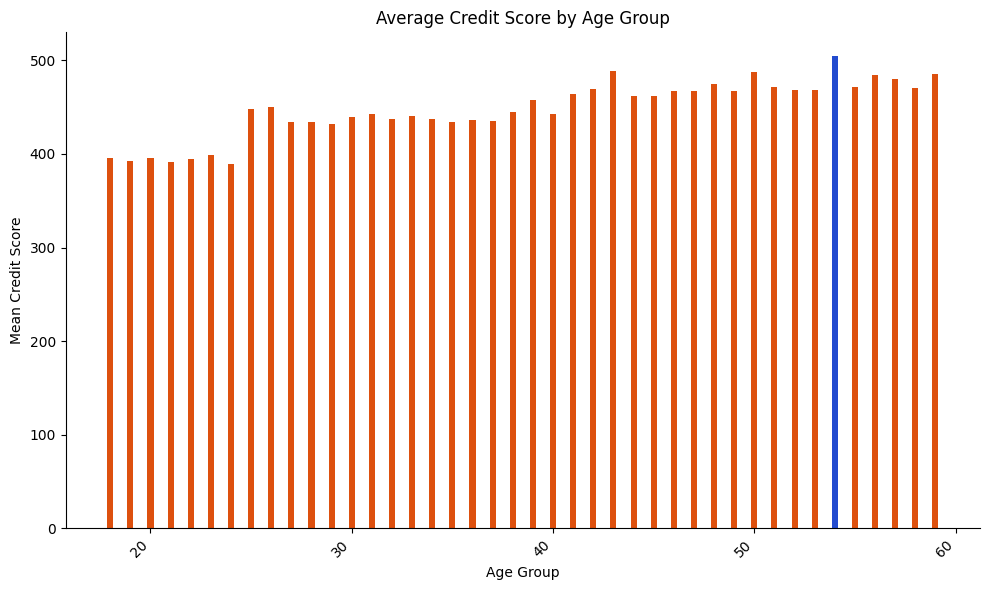

In [93]:
#Grouping by age and calculating the mean credit score
avg_credit_by_age = df.groupby('age')['credit_score'].mean().reset_index()

#Plot and default color
plt.figure(figsize=(10,6))
colors = ["#dd500e"]*len(avg_credit_by_age)

#Bar Color
max_index = avg_credit_by_age['credit_score'].idxmax()
highlight_position = avg_credit_by_age.index.get_loc(max_index)
colors[max_index] = "#123eccee"

plt.bar(avg_credit_by_age['age'], avg_credit_by_age['credit_score'], color = colors, width =0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Age Group")
plt.ylabel("Mean Credit Score")
plt.title("Average Credit Score by Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()